In [9]:
import os
import sys
import json
import glob
import warnings
import numpy as np
import xarray as xr
import proplot as pplt
from matplotlib.patches import Patch
warnings.filterwarnings('ignore')
pplt.rc.update({'figure.dpi':100,'reso':'xx-hi'})

In [10]:
with open('../scripts/configs.json','r',encoding='utf-8') as f:
    CONFIGS = json.load(f)
SPLITSDIR  = CONFIGS['filepaths']['splits']    
MODELSDIR  = CONFIGS['filepaths']['models']
PREDSDIR   = CONFIGS['filepaths']['predictions']
MODELS     = CONFIGS['experiments']
LATRANGE   = CONFIGS['domain']['latrange']
LONRANGE   = CONFIGS['domain']['lonrange']
SPLIT      = 'valid'   
PRTHRESH   = 0.03

In [43]:
results = []
for group in ['pod','nn']:
    for name,_ in MODELS[group]['runs'].items():
        if name.startswith('NEW_'):
            if 'tp' in name:
                truepr = xr.open_dataset(os.path.join(SPLITSDIR,f'{SPLIT}.h5'),engine='h5netcdf').tp.load()
            elif 'pr' in name:
                truepr = xr.open_dataset(os.path.join(SPLITSDIR,f'{SPLIT}.h5'),engine='h5netcdf').pr.load()
            filepath = os.path.join(PREDSDIR,f'{name}_{SPLIT}_predictions.nc')
            if os.path.exists(filepath):
                with xr.open_dataset(filepath) as ds:
                    predpr  = ds.pr.load()
                ytrue,ypred = xr.align(truepr,predpr,join='inner')
                # ytrue,ypred = ytrue.where(ytrue>=0.0001,0.0),ypred.where(ypred>=0.0001,0.0)
                results.append((name,ytrue,ypred))
print(f'Found {len(results)} models with predictions!')

resultspr = [(n,ytrue,ypred) for n,ytrue,ypred in results if 'pr' in n]
resultstp = [(n,ytrue,ypred) for n,ytrue,ypred in results if 'tp' in n]
print(f'- pr: {len(resultspr)} models')
print(f'- tp: {len(resultstp)} models')

Found 10 models with predictions!
- pr: 5 models
- tp: 5 models


In [44]:
def get_global_range(results):
    allvals = []
    for _,ytrue,ypred in results:
        ytrue = ytrue.values.ravel()
        ypred = ypred.values.ravel()
        allvals.append(ytrue)
        allvals.append(ypred)
    allvals = np.concatenate(allvals)
    allvals = allvals[np.isfinite(allvals)&(allvals>0)]
    return allvals.min(),allvals.max()

globalminpr,globalmaxpr = get_global_range(resultspr)
globalmintp,globalmaxtp = get_global_range(resultstp)
print(f'pr range: [{globalminpr:.2e}, {globalmaxpr:.2e}]')
print(f'tp range: [{globalmintp:.2e}, {globalmaxtp:.2e}]')

pr range: [3.45e-17, 1.03e+02]
tp range: [4.47e-07, 1.82e+02]


In [45]:
def get_r2(ytrue,ypred,dims=None):
    dims  = list(ytrue.dims) if dims is None else dims
    ssres = ((ytrue-ypred)**2).sum(dim=dims,skipna=True)
    sstot = ((ytrue-ytrue.mean(dim=dims,skipna=True))**2).sum(dim=dims,skipna=True)
    return 1-ssres/sstot

In [46]:
def plot_r2_bars(results,suptitle):
    names,r2means,colors = [],[],[]
    seeds  = any(('seed' in get_r2(ytrue,ypred,dims=None).dims and get_r2(ytrue,ypred,dims=None).sizes.get('seed',0)>1) 
                 for _,ytrue,ypred in results)
    r2stds = [] if seeds else None
    for name,ytrue,ypred in results:
        r2   = get_r2(ytrue,ypred,dims=None)
        seed = 'seed' in r2.dims and r2.sizes.get('seed',0)>1
        r2mean,r2std = (r2.mean('seed'),r2.std('seed')) if seed else (r2,None)
        names.append(name)
        r2means.append(float(r2mean))
        if seeds:
            r2stds.append(float(r2std) if r2std is not None else 0.0)
        colors.append('gray6' if 'pod' in name else 'blue6' if 'hurdle' in name else 'red6')
    order   = np.argsort(r2means)
    names   = [names[i] for i in order]
    r2means = [r2means[i] for i in order]
    colors  = [colors[i] for i in order]
    if seeds:
        r2stds = [r2stds[i] for i in order]
    fig,ax = pplt.subplots(nrows=1,ncols=1,refwidth=6,refheight=3)
    ax.format(suptitle=suptitle,grid=False,xminorticks='none')
    bars = ax.barh(names,r2means,xerr=(r2stds if seeds else None),color=colors,capsize=(3 if seeds else 0))
    for bar,r2mean in zip(bars,r2means):
        ax.text(bar.get_width()-0.015,bar.get_y()+bar.get_height()/2,f'{r2mean:.3f}',va='center',ha='left')
    pplt.show()

def plot_density_panels(results,globalmin,globalmax,nbins,suptitle):
    n=len(results); ncols=int(np.ceil(np.sqrt(n))); nrows=int(np.ceil(n/ncols))
    binedges = np.logspace(np.log10(globalmin),np.log10(globalmax),nbins+1)
    arr = np.arange(1,nrows*ncols+1).reshape(nrows,ncols); arr[arr>n]=0
    fig,axs = pplt.subplots(array=arr,refwidth=2,share=True)
    axs.format(suptitle=suptitle,xlabel='Observed',ylabel='Predicted')
    axs = np.atleast_1d(axs).ravel()
    for ax,(name,ytrue,ypred) in zip(axs,results):
        r2   = get_r2(ytrue,ypred,dims=None)
        seed = 'seed' in r2.dims and r2.sizes.get('seed',0)>1
        r2mean,r2std = (r2.mean('seed'),r2.std('seed')) if seed else (r2,None)
        ypredmean = ypred.mean('seed') if seed else ypred
        ytrueflat  = ytrue.values.ravel()
        ypredflat  = ypredmean.values.ravel()
        mask = (np.isfinite(ytrueflat)&np.isfinite(ypredflat)&(ytrueflat>0)&(ypredflat>0))
        hist,_,_ = np.histogram2d(ytrueflat[mask],ypredflat[mask],bins=[binedges,binedges])
        hist = np.ma.masked_where(hist==0,hist)
        im = ax.pcolormesh(binedges,binedges,hist.T,cmap='ColdHot',norm='log',extend='both')
        ax.plot([globalmin,globalmax],[globalmin,globalmax],color='k',linewidth=1,linestyle='--')
        text = f'R$^2$ = {float(r2mean):.3f}'+(f' ± {float(r2std):.3f}' if seed else '')
        ax.text(0.02,0.98,text,transform=ax.transAxes,va='top',ha='left')
        ticks = [globalmin,1e-6,1e-4,1e-2,1e0,globalmax]
        ax.format(title=name,
                  xscale='log',xformatter='log',xlim=(globalmin,globalmax),xticks=ticks,xminorticks='none',
                  yscale='log',yformatter='log',ylim=(globalmin,globalmax),yticks=ticks,yminorticks='none')
    fig.colorbar(im,loc='r',label='Counts')
    pplt.show()

def plot_rain_distribution_panels(results,globalmin,globalmax,suptitle,spacing=0.07,density=False):
    n=len(results); ncols=int(np.ceil(np.sqrt(n))); nrows=int(np.ceil(n/ncols))
    r = 1.0+spacing
    kmax    = int(np.ceil(np.log(globalmax/globalmin)/np.log(r)))
    bincenters = globalmin*(r**np.arange(kmax+1))
    binedges   = np.concatenate([bincenters/np.sqrt(r),[bincenters[-1]*np.sqrt(r)]])
    arr = np.arange(1,nrows*ncols+1).reshape(nrows,ncols); arr[arr>n]=0
    fig,axs = pplt.subplots(array=arr,refwidth=2,share=True)
    ylabel  = 'Density' if density else 'Count'
    axs.format(suptitle=suptitle,grid=False,xlabel='Precipitation Rate (mm/hr)',ylabel=ylabel)
    axs = np.atleast_1d(axs).ravel()
    for ax,(name,ytrue,ypred) in zip(axs,results):
        r2 = get_r2(ytrue,ypred,dims=None)
        seed = 'seed' in r2.dims and r2.sizes.get('seed',0)>1
        r2mean,r2std = (r2.mean('seed'),r2.std('seed')) if seed else (r2,None)
        ypredmean = ypred.mean('seed') if seed else ypred
        ytrueflat = ytrue.values.ravel()
        ypredflat = ypredmean.values.ravel()
        truemask0 = np.isfinite(ytrueflat)&(ytrueflat>=0)
        predmask0 = np.isfinite(ypredflat)&(ypredflat>=0)
        truemask  = truemask0&(ytrueflat>globalmin)
        predmask  = predmask0&(ypredflat>globalmin)
        drytrue = 1.0-(truemask.sum()/max(truemask0.sum(),1))
        drypred = 1.0-(predmask.sum()/max(predmask0.sum(),1))
        histtrue,_ = np.histogram(ytrueflat[truemask],bins=binedges,density=density)
        histpred,_ = np.histogram(ypredflat[predmask],bins=binedges,density=density)
        ax.step(bincenters,histtrue,where='mid',color='k',label='Observed')
        ax.step(bincenters,histpred,where='mid',color='red6',label='Predicted')
        text = f'R$^2$ = {float(r2mean):.3f}'+(f' ± {float(r2std):.3f}' if seed else '')
        ax.text(0.02,0.88,text,transform=ax.transAxes,va='top',ha='left')
        ax.text(0.02,0.98,f'{drytrue:.0%} vs.         Dry',transform=ax.transAxes,va='top',ha='left')
        ax.text(0.25,0.98,f'{drypred:.0%}',transform=ax.transAxes,va='top',ha='left',color='red6')
        ax.format(title=name,xscale='log',xformatter='log',xlim=(globalmin,globalmax),xminorticks='none',yminorticks='none')
    # axs[0].legend(loc='cl',ncols=1,frame=False)
    pplt.show()

def plot_bias_maps(results, title='Time-Mean Precipitation Bias'):
    names,biases = [],[]
    for name,ytrue,ypred in results:
        ypredmean = ypred.mean('seed') if ('seed' in ypred.dims and ypred.sizes.get('seed',0)>1) else ypred
        bias = (ypredmean-ytrue).mean('time').squeeze()
        names.append(name)
        biases.append(bias)
    n=len(biases); ncols=int(np.ceil(np.sqrt(n))); nrows=int(np.ceil(n/ncols))
    arr = np.arange(1,nrows*ncols+1).reshape(nrows,ncols); arr[arr>n]=0
    fig,axs = pplt.subplots(array=arr,proj='cyl',refwidth=2,share=False)
    axs.format(suptitle=title,grid=False,coast=True,
               latlim=LATRANGE,latlines=5,lonlim=LONRANGE,lonlines=5)
    axs  = np.atleast_1d(axs).ravel()
    vmax = max(float(abs(b).max()) for b in biases)
    for ax,name,bias in zip(axs,names,biases):
        im = ax.pcolormesh(bias.lon,bias.lat,bias,cmap='ColdHot',vmin=-vmax,vmax=vmax,levels=21,extend='both')
        ax.format(title=name)
    fig.colorbar(im,loc='b',label='Precipitation Bias (mm/hr)')
    pplt.show()

def plot_r2_maps(results, title='Time-Mean R$^2$'):
    n=len(results); ncols=int(np.ceil(np.sqrt(n))); nrows=int(np.ceil(n/ncols))
    arr = np.arange(1,nrows*ncols+1).reshape(nrows,ncols); arr[arr>n]=0
    fig,axs = pplt.subplots(array=arr,refwidth=2,proj='cyl',share=False)
    axs.format(suptitle=title,grid=False,coast=True,latlim=LATRANGE,lonlim=LONRANGE)
    axs = np.atleast_1d(axs).ravel()
    for ax,(name,ytrue,ypred) in zip(axs,results):
        r2 = get_r2(ytrue,ypred,dims=['time'])
        seed = 'seed' in r2.dims and r2.sizes.get('seed',0)>1
        r2mean,_ = ((r2.mean('seed').squeeze(),r2.std('seed')) if seed else (r2.squeeze(),None))
        im = ax.pcolormesh(r2mean.lon,r2mean.lat,r2mean,cmap='ColdHot',cmap_kw={'left':0.5},vmin=0,vmax=0.5,levels=20,extend='both')
        ax.format(title=name)
    fig.colorbar(im,loc='b',label='R$^2$',ticks=0.1)
    pplt.show()

def plot_confusion_matrix(results, prthresh=PRTHRESH, title=None):
    n=len(results); ncols=int(np.ceil(np.sqrt(n))); nrows=int(np.ceil(n/ncols))
    arr = np.arange(1,nrows*ncols+1).reshape(nrows,ncols); arr[arr>n]=0
    fig,axs = pplt.subplots(array=arr,refwidth=2,share=True)
    axs     = np.atleast_1d(axs).ravel()
    labels  = [('TN',0,0,0.5,0.5),('FP',0,1,1.5,0.5),('FN',1,0,0.5,1.5),('TP',1,1,1.5,1.5)]
    suptitle = title if title else f'Confusion Matrix (Threshold = {prthresh} mm/hr)'
    for ax,(name,ytrue,ypred) in zip(axs,results):
        ytrueabove,ypredabove = ytrue>prthresh,ypred>prthresh
        dims = list(ytrue.dims)
        tp = (ypredabove&ytrueabove).sum(dim=dims,skipna=True)
        tn = (~ypredabove&~ytrueabove).sum(dim=dims,skipna=True)
        fp = (ypredabove&~ytrueabove).sum(dim=dims,skipna=True)
        fn = (~ypredabove&ytrueabove).sum(dim=dims,skipna=True)
        total = tp+fp+fn+tn
        seed  = hasattr(total,'dims') and ('seed' in total.dims and total.sizes.get('seed',0)>1)
        if seed:
            pct = [100.0*x/total for x in (tn,fp,fn,tp)]
            mean,std   = [p.mean('seed') for p in pct],[p.std('seed') for p in pct]
            matrixmean = np.array([[mean[0],mean[1]],[mean[2],mean[3]]],dtype=float)
            matrixstd  = np.array([[std[0],std[1]],[std[2],std[3]]],dtype=float)
        else:
            matrixmean = 100.0*np.array([[float(tn),float(fp)],[float(fn),float(tp)]],dtype=float)/float(total)
            matrixstd  = np.zeros((2,2))
        im = ax.pcolormesh([0,1,2],[0,1,2],matrixmean,cmap='Blues',vmin=0,vmax=100,levels=111)
        for label,i,j,x,y in labels:
            text = f'{label}\n{matrixmean[i,j]:.1f}{" ± "+f"{matrixstd[i,j]:.1f}%" if seed else "%"}'
            ax.text(x,y,text,ha='center',va='center')
        ax.format(suptitle=suptitle,title=name,
                  xlim=(0,2),xticks=[0.5,1.5],xticklabels=['Predicted Dry','Predicted Wet'],xminorticks='none',
                  ylim=(0,2),yticks=[0.5,1.5],yticklabels=['Observed\nDry','Observed\nWet'],yminorticks='none')
    fig.colorbar(im,loc='r',ticks=10,label='Percent of Samples')
    pplt.show()

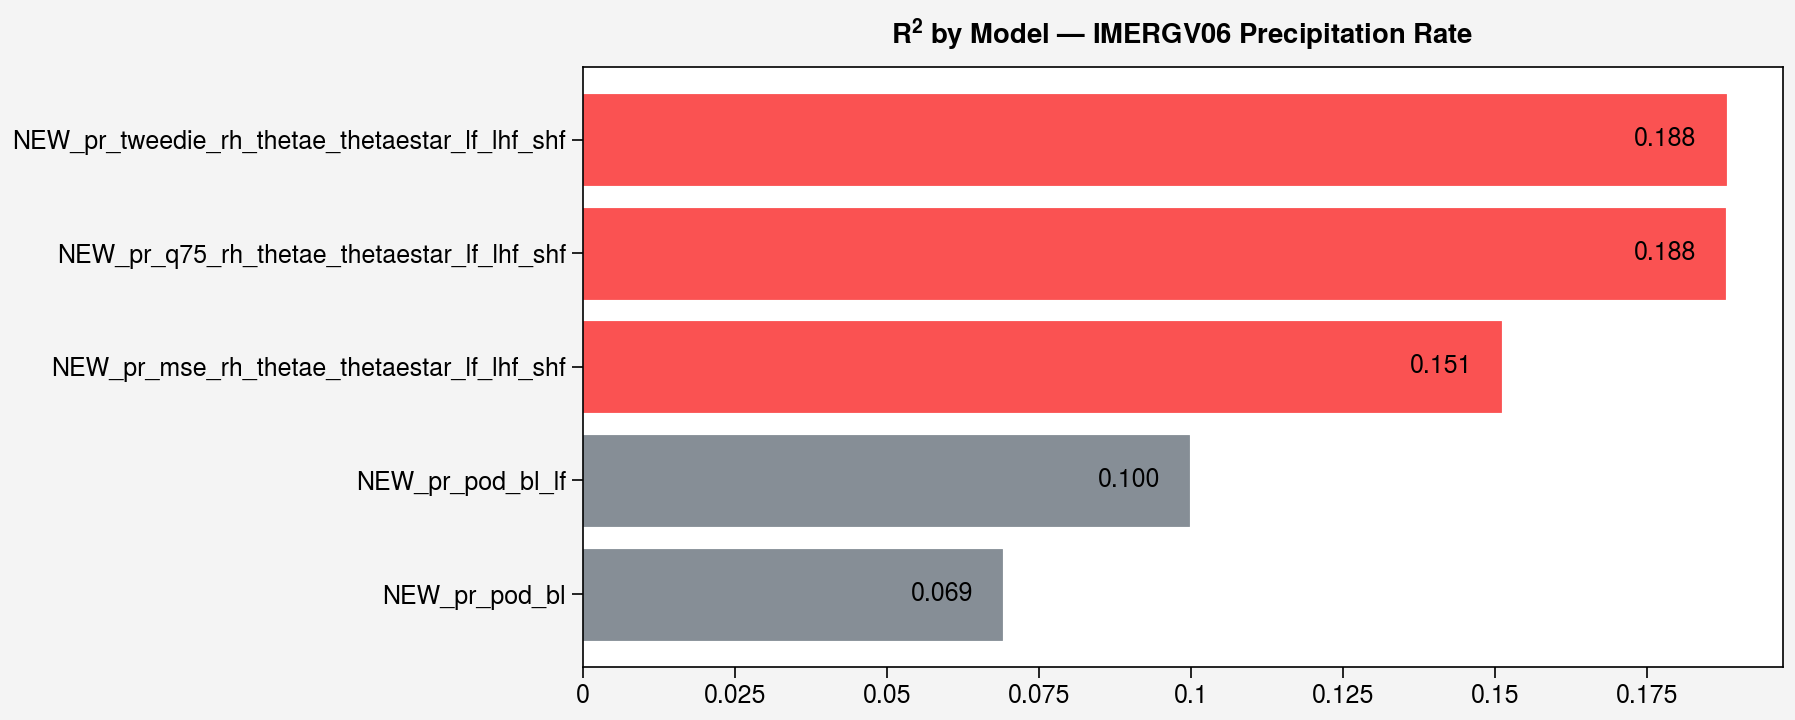

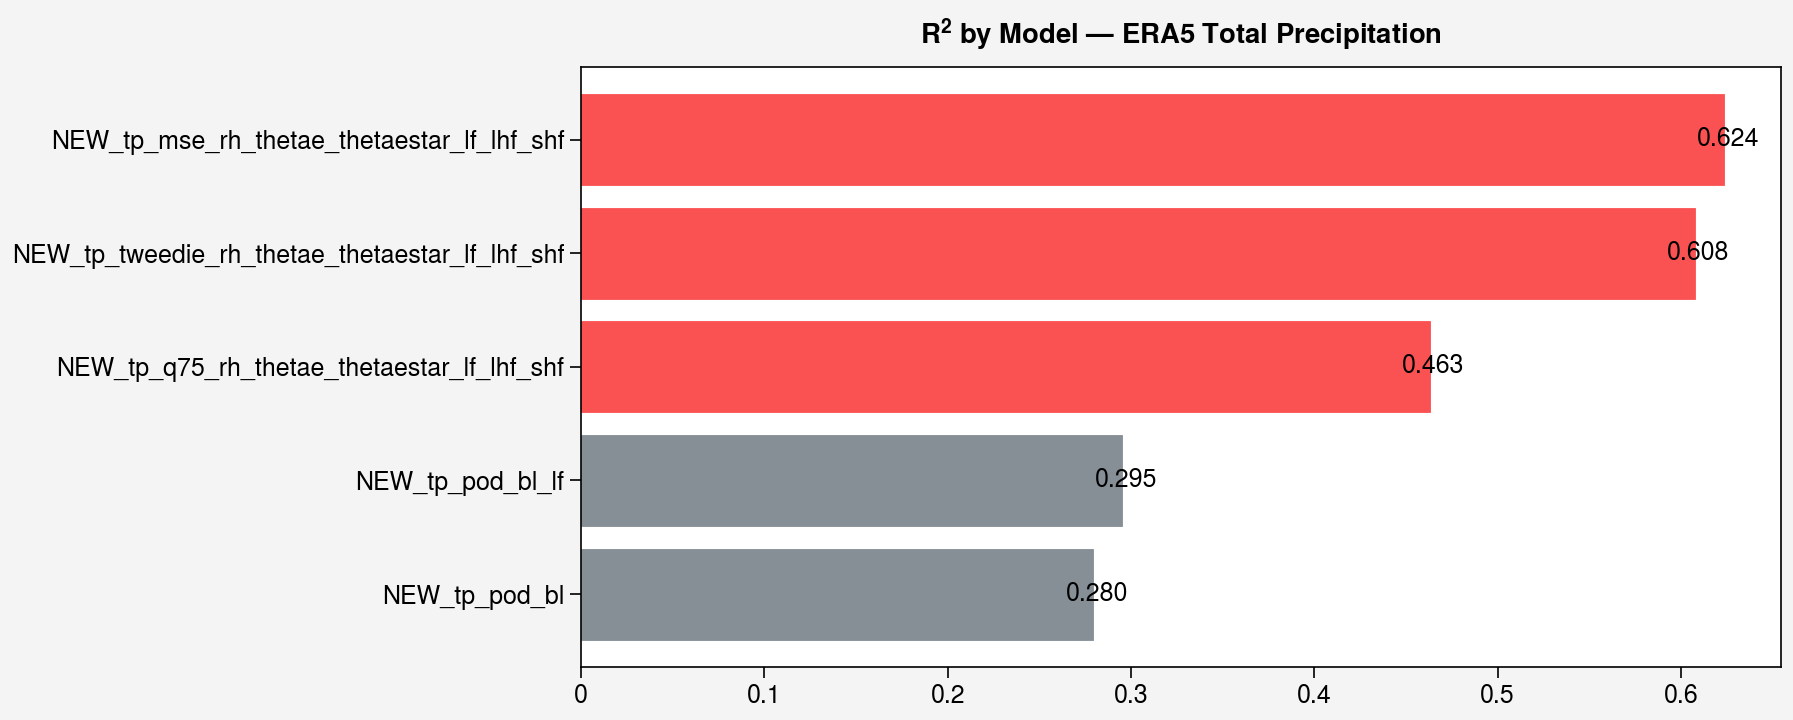

In [47]:
plot_r2_bars(resultspr,'R$^2$ by Model — IMERGV06 Precipitation Rate')
plot_r2_bars(resultstp,'R$^2$ by Model — ERA5 Total Precipitation')

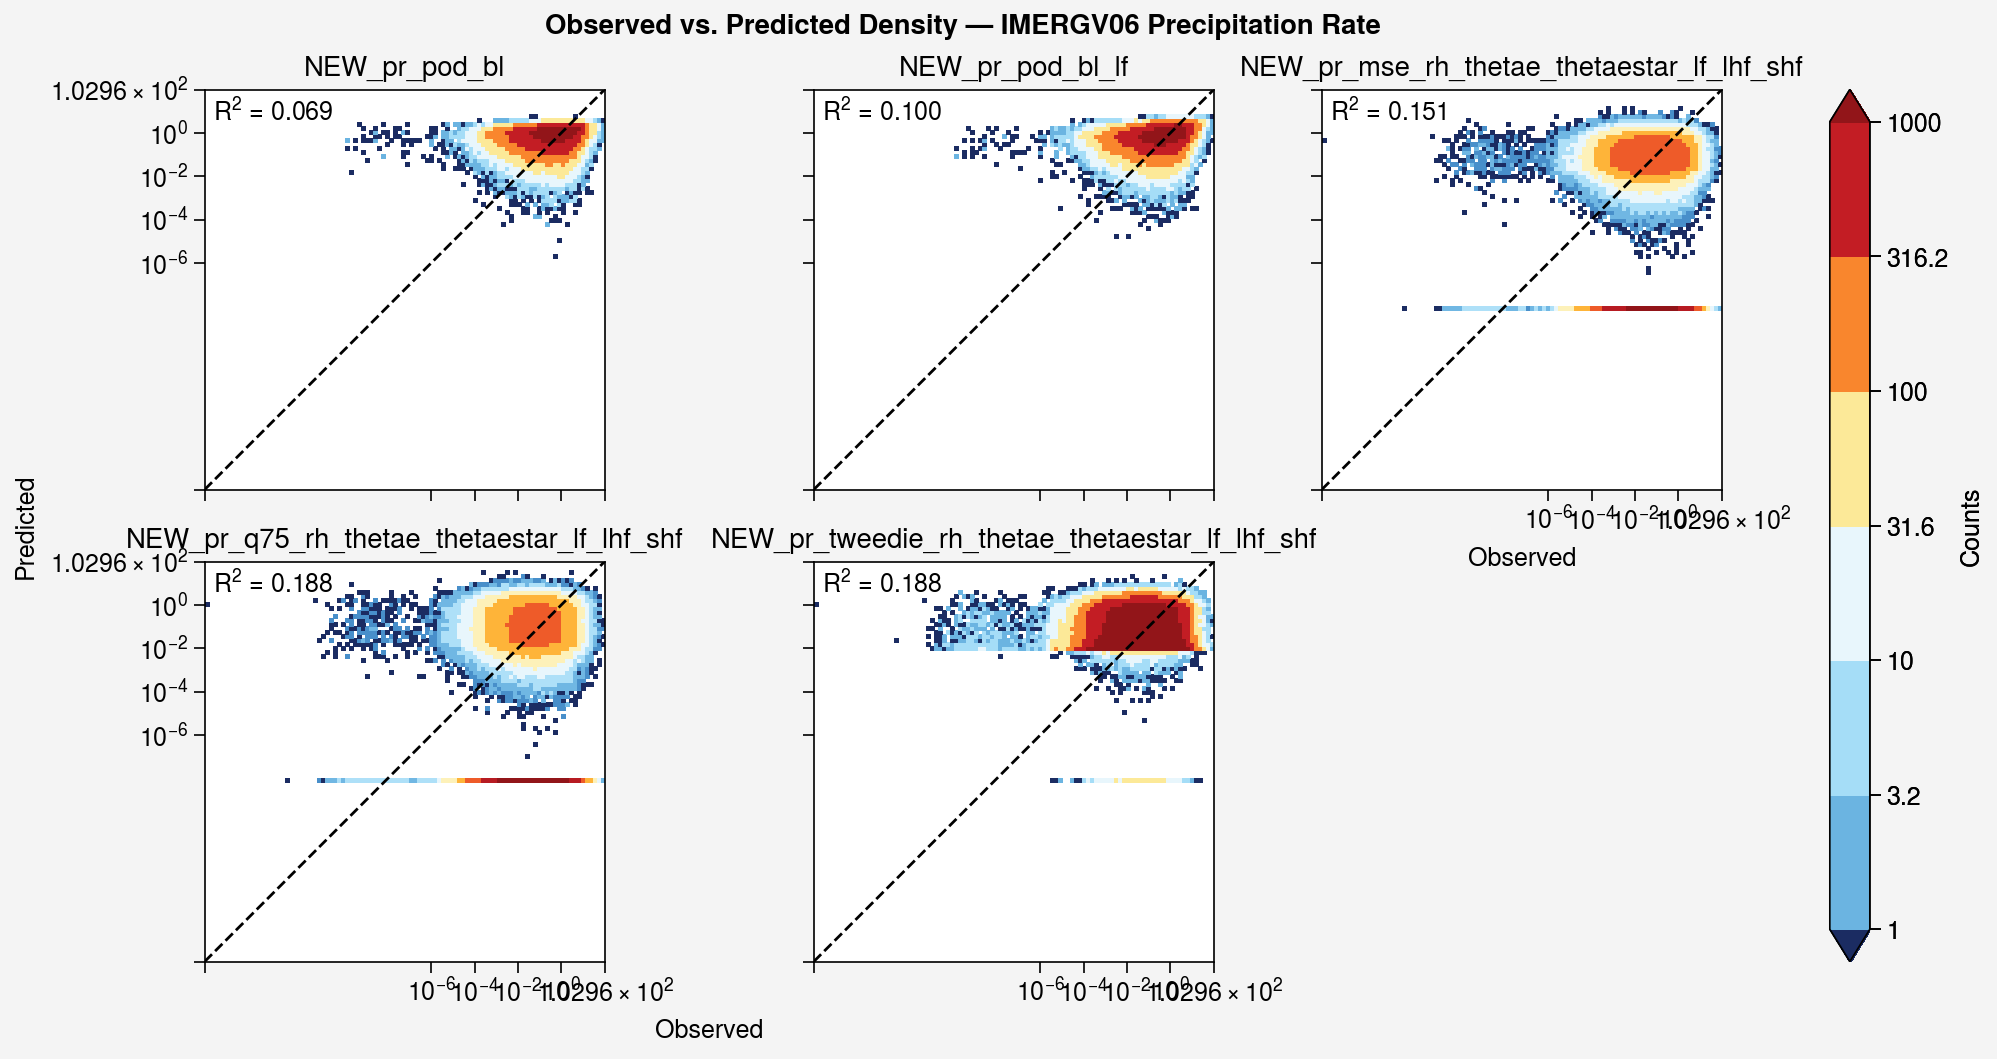

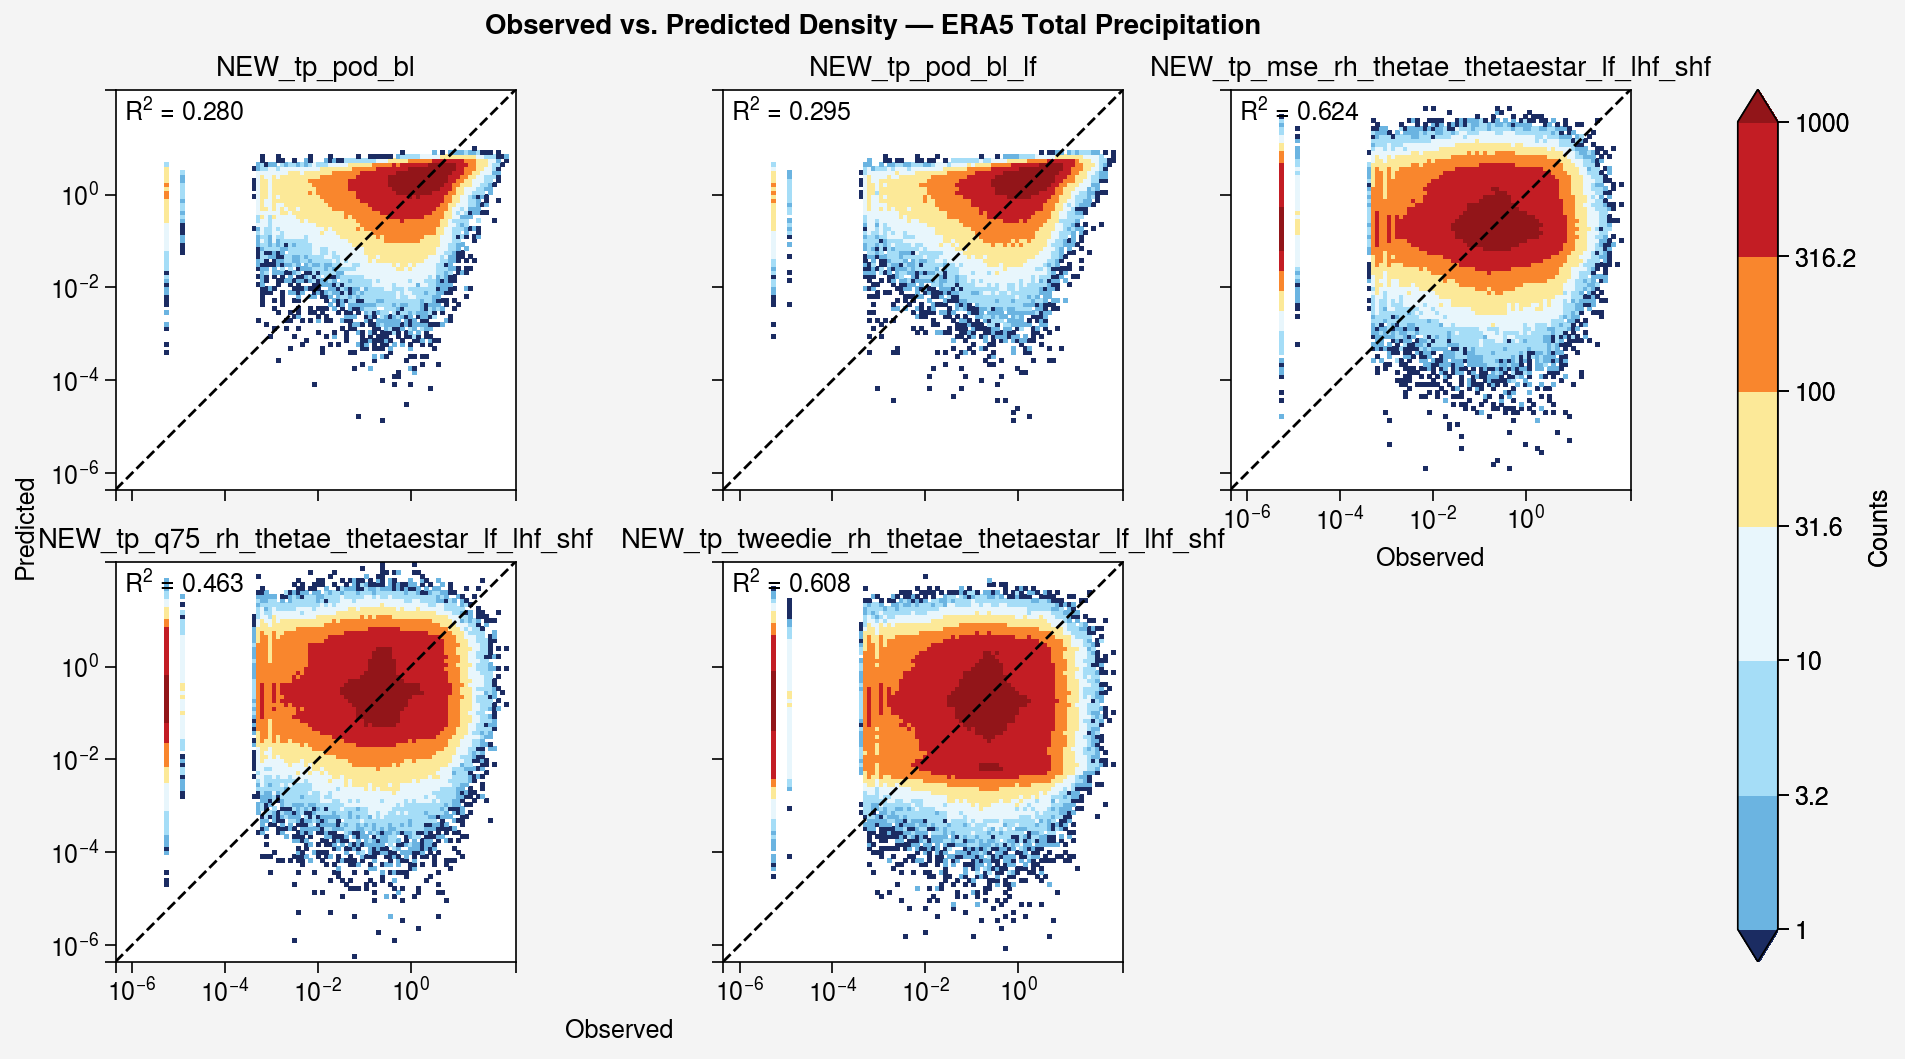

In [48]:
plot_density_panels(resultspr,globalminpr,globalmaxpr,100,'Observed vs. Predicted Density — IMERGV06 Precipitation Rate')
plot_density_panels(resultstp,globalmintp,globalmaxtp,100,'Observed vs. Predicted Density — ERA5 Total Precipitation')

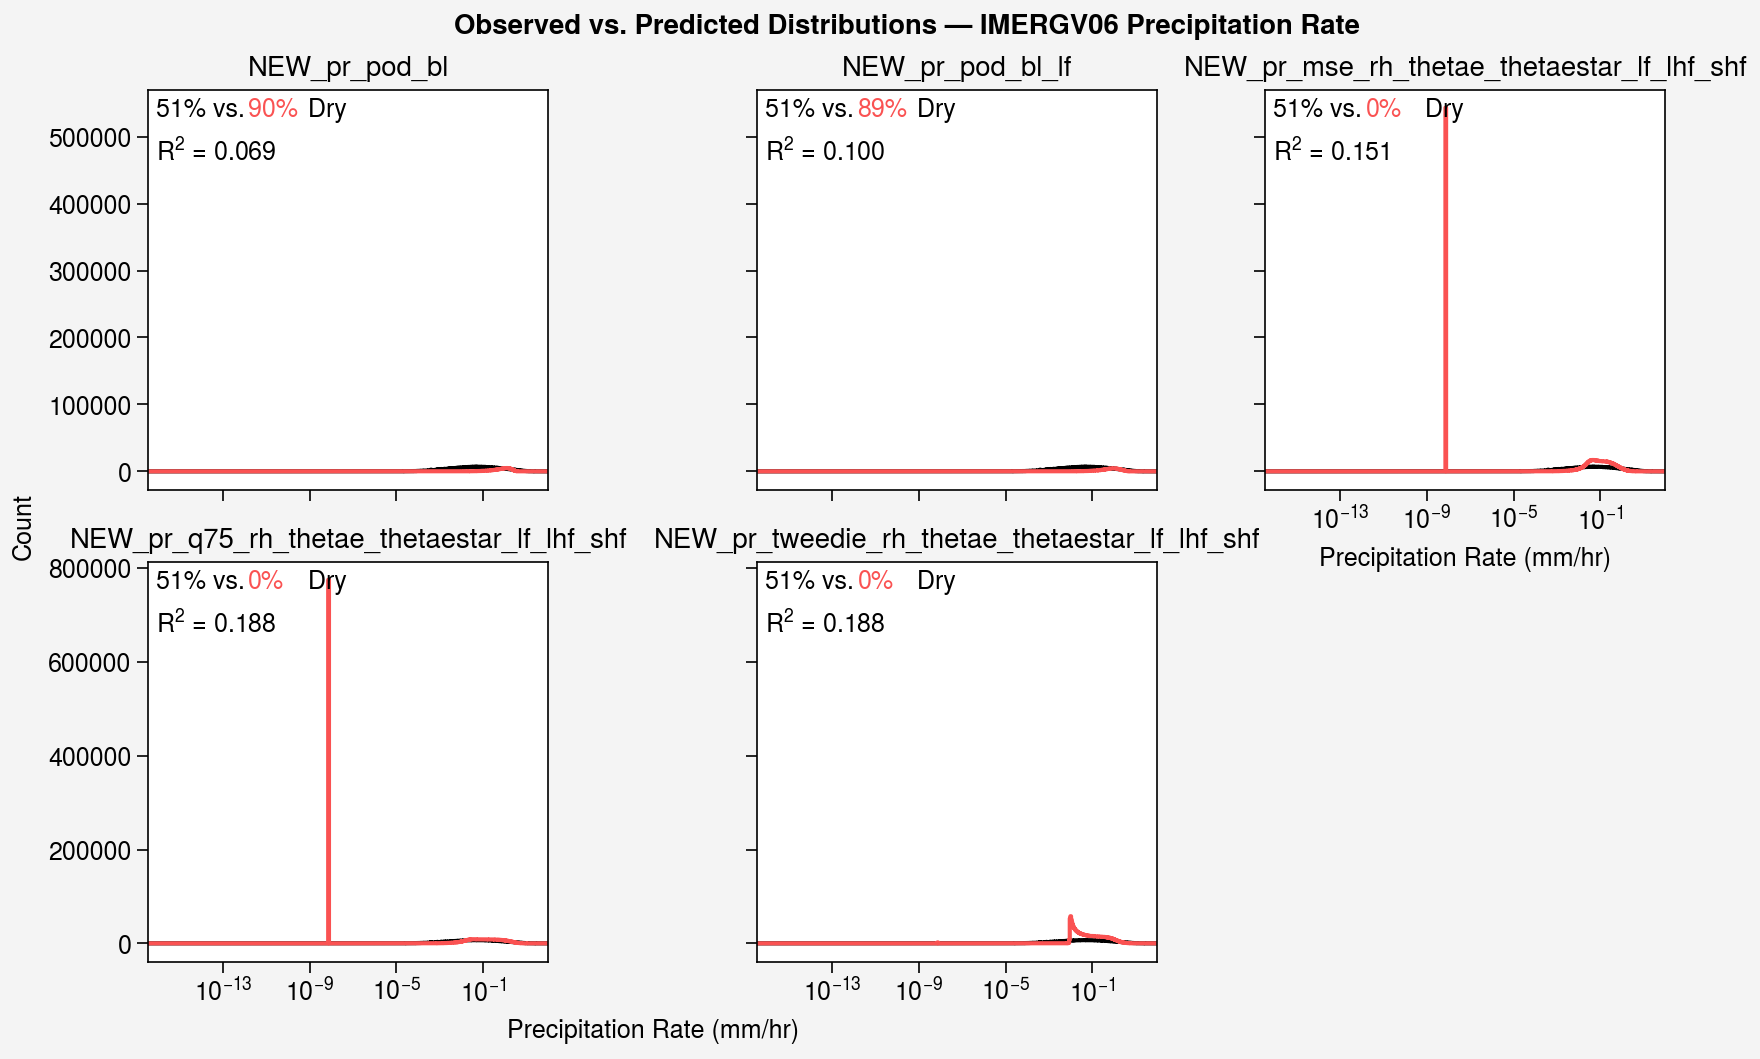

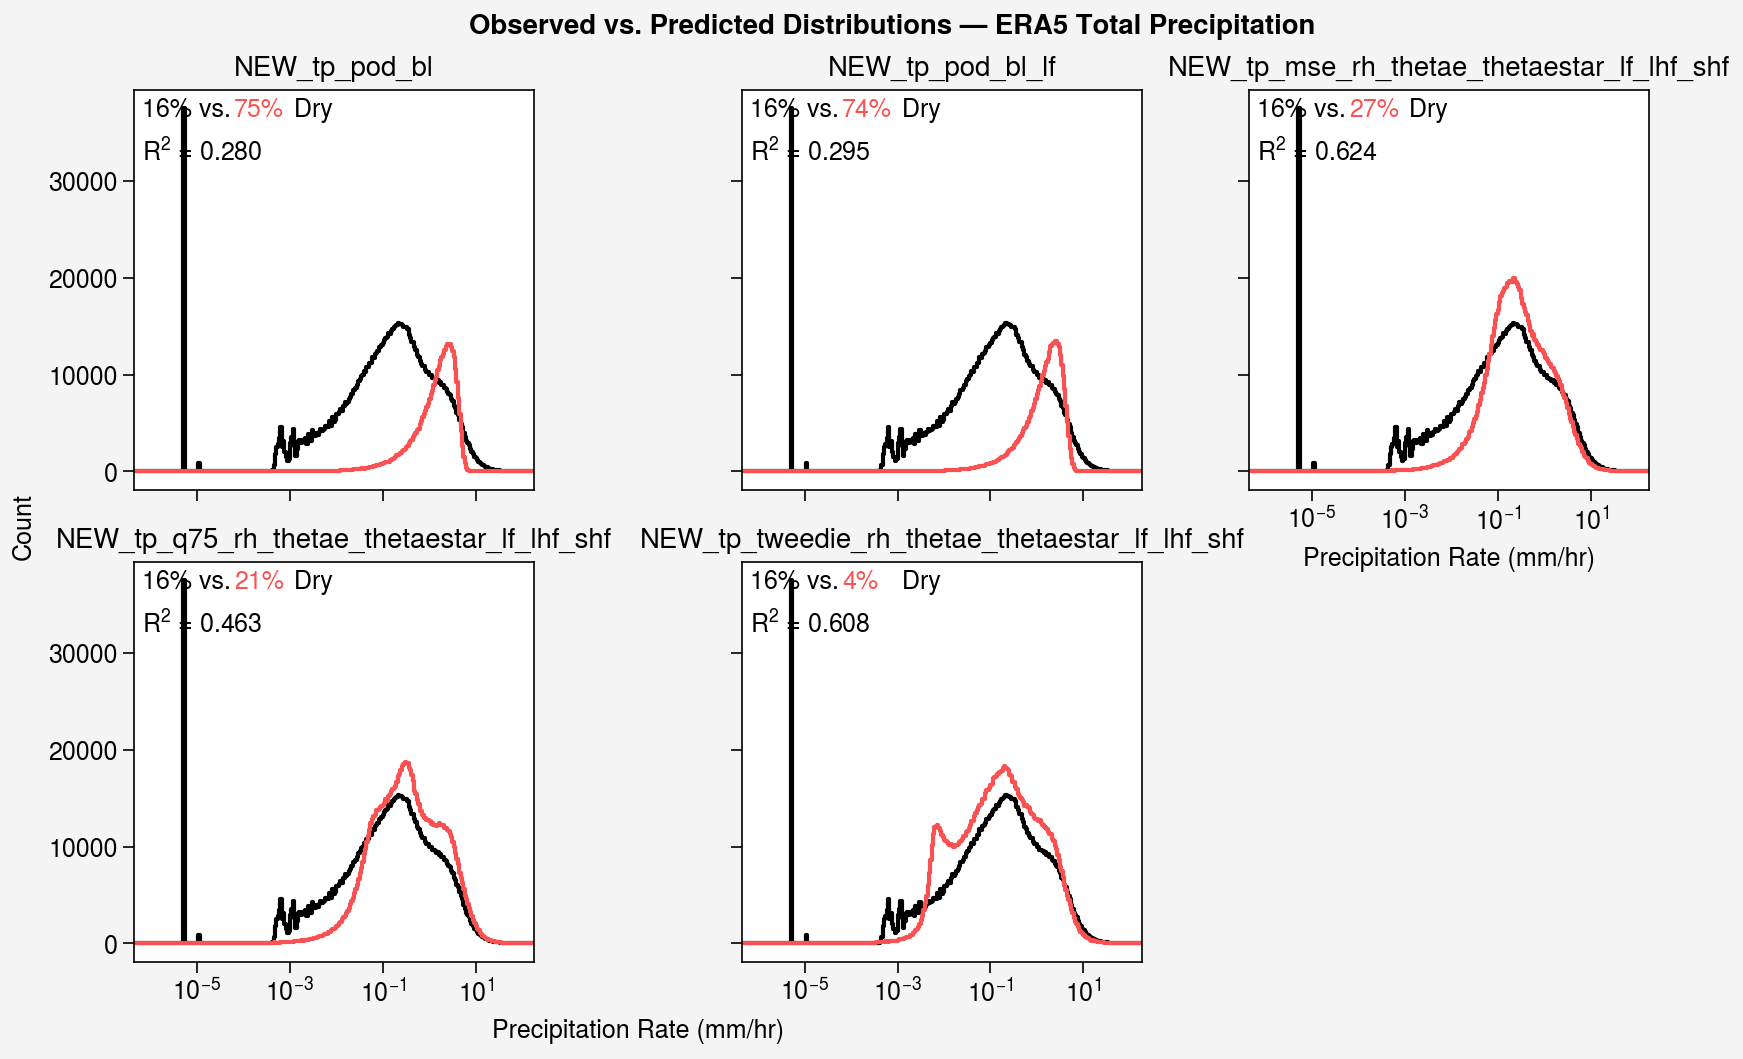

In [49]:
plot_rain_distribution_panels(resultspr,globalminpr,globalmaxpr,'Observed vs. Predicted Distributions — IMERGV06 Precipitation Rate')
plot_rain_distribution_panels(resultstp,globalmintp,globalmaxtp,'Observed vs. Predicted Distributions — ERA5 Total Precipitation')

In [50]:
def plot_bias_maps(results,suptitle):
    names,biases = [],[]
    for name,ytrue,ypred in results:
        ypredmean = ypred.mean('seed') if ('seed' in ypred.dims and ypred.sizes.get('seed',0)>1) else ypred
        bias = (ypredmean-ytrue).mean('time').squeeze()
        names.append(name)
        biases.append(bias)
    n=len(biases); ncols=int(np.ceil(np.sqrt(n))); nrows=int(np.ceil(n/ncols))
    arr = np.arange(1,nrows*ncols+1).reshape(nrows,ncols); arr[arr>n]=0
    fig,axs = pplt.subplots(array=arr,proj='cyl',refwidth=2,share=False)
    axs.format(suptitle=suptitle,grid=False,coast=True,
               latlim=LATRANGE,latlines=5,lonlim=LONRANGE,lonlines=5)
    axs  = np.atleast_1d(axs).ravel()
    vmax = max(float(abs(b).max()) for b in biases)
    for ax,name,bias in zip(axs,names,biases):
        im = ax.pcolormesh(bias.lon,bias.lat,bias,cmap='ColdHot',vmin=-vmax,vmax=vmax,levels=21,extend='both')
        ax.format(title=name)
    fig.colorbar(im,loc='b',label='Precipitation Bias (mm/hr)')
    pplt.show()

def plot_r2_maps(results,suptitle):
    n=len(results); ncols=int(np.ceil(np.sqrt(n))); nrows=int(np.ceil(n/ncols))
    arr = np.arange(1,nrows*ncols+1).reshape(nrows,ncols); arr[arr>n]=0
    fig,axs = pplt.subplots(array=arr,refwidth=2,proj='cyl',share=False)
    axs.format(suptitle=suptitle,grid=False,coast=True,latlim=LATRANGE,lonlim=LONRANGE)
    axs = np.atleast_1d(axs).ravel()
    for ax,(name,ytrue,ypred) in zip(axs,results):
        r2 = get_r2(ytrue,ypred,dims=['time'])
        seed = 'seed' in r2.dims and r2.sizes.get('seed',0)>1
        r2mean,_ = ((r2.mean('seed').squeeze(),r2.std('seed')) if seed else (r2.squeeze(),None))
        im = ax.pcolormesh(r2mean.lon,r2mean.lat,r2mean,cmap='ColdHot',cmap_kw={'left':0.5},vmin=0,vmax=0.5,levels=20,extend='both')
        ax.format(title=name)
    fig.colorbar(im,loc='b',label='R$^2$',ticks=0.1)
    pplt.show()
    
def plot_confusion_matrix(results,suptitle,prthresh=PRTHRESH):
    n=len(results); ncols=int(np.ceil(np.sqrt(n))); nrows=int(np.ceil(n/ncols))
    arr = np.arange(1,nrows*ncols+1).reshape(nrows,ncols); arr[arr>n]=0
    fig,axs = pplt.subplots(array=arr,refwidth=2,share=True)
    axs     = np.atleast_1d(axs).ravel()
    labels  = [('TN',0,0,0.5,0.5),('FP',0,1,1.5,0.5),('FN',1,0,0.5,1.5),('TP',1,1,1.5,1.5)]
    for ax,(name,ytrue,ypred) in zip(axs,results):
        ytrueabove,ypredabove = ytrue>prthresh,ypred>prthresh
        dims = list(ytrue.dims)
        tp = (ypredabove&ytrueabove).sum(dim=dims,skipna=True)
        tn = (~ypredabove&~ytrueabove).sum(dim=dims,skipna=True)
        fp = (ypredabove&~ytrueabove).sum(dim=dims,skipna=True)
        fn = (~ypredabove&ytrueabove).sum(dim=dims,skipna=True)
        total = tp+fp+fn+tn
        seed  = hasattr(total,'dims') and ('seed' in total.dims and total.sizes.get('seed',0)>1)
        if seed:
            pct = [100.0*x/total for x in (tn,fp,fn,tp)]
            mean,std   = [p.mean('seed') for p in pct],[p.std('seed') for p in pct]
            matrixmean = np.array([[mean[0],mean[1]],[mean[2],mean[3]]],dtype=float)
            matrixstd  = np.array([[std[0],std[1]],[std[2],std[3]]],dtype=float)
        else:
            matrixmean = 100.0*np.array([[float(tn),float(fp)],[float(fn),float(tp)]],dtype=float)/float(total)
            matrixstd  = np.zeros((2,2))
        im = ax.pcolormesh([0,1,2],[0,1,2],matrixmean,cmap='Blues',vmin=0,vmax=100,levels=111)
        for label,i,j,x,y in labels:
            text = f'{label}\n{matrixmean[i,j]:.1f}{" ± "+f"{matrixstd[i,j]:.1f}%" if seed else "%"}'
            ax.text(x,y,text,ha='center',va='center')
        ax.format(suptitle=suptitle,title=name,
                  xlim=(0,2),xticks=[0.5,1.5],xticklabels=['Predicted Dry','Predicted Wet'],xminorticks='none',
                  ylim=(0,2),yticks=[0.5,1.5],yticklabels=['Observed\nDry','Observed\nWet'],yminorticks='none')
    fig.colorbar(im,loc='r',ticks=10,label='Percent of Samples')
    pplt.show()

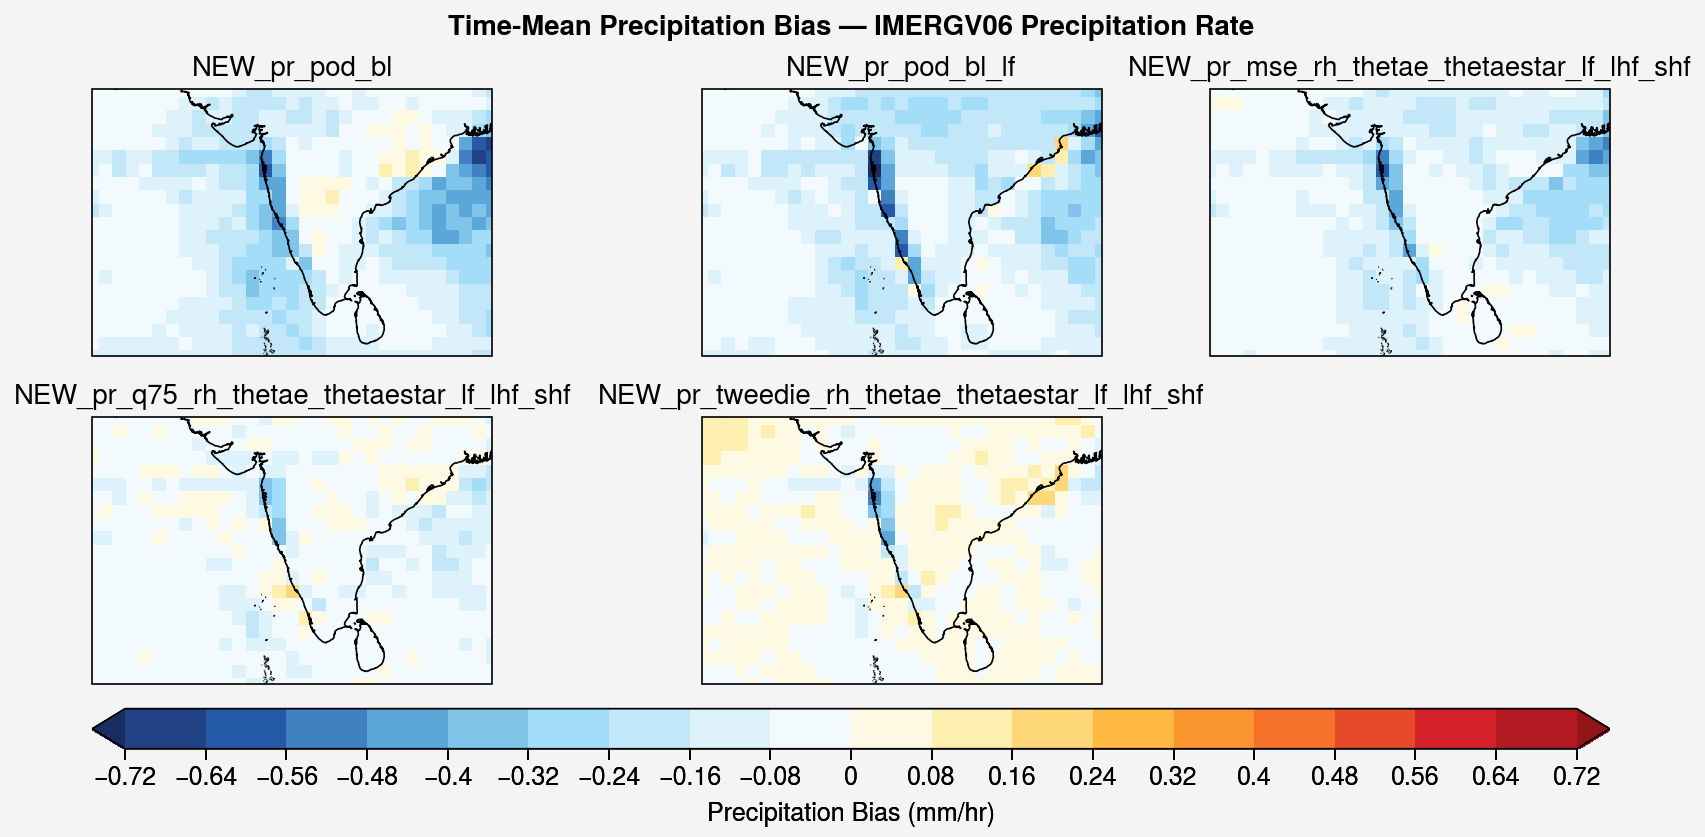

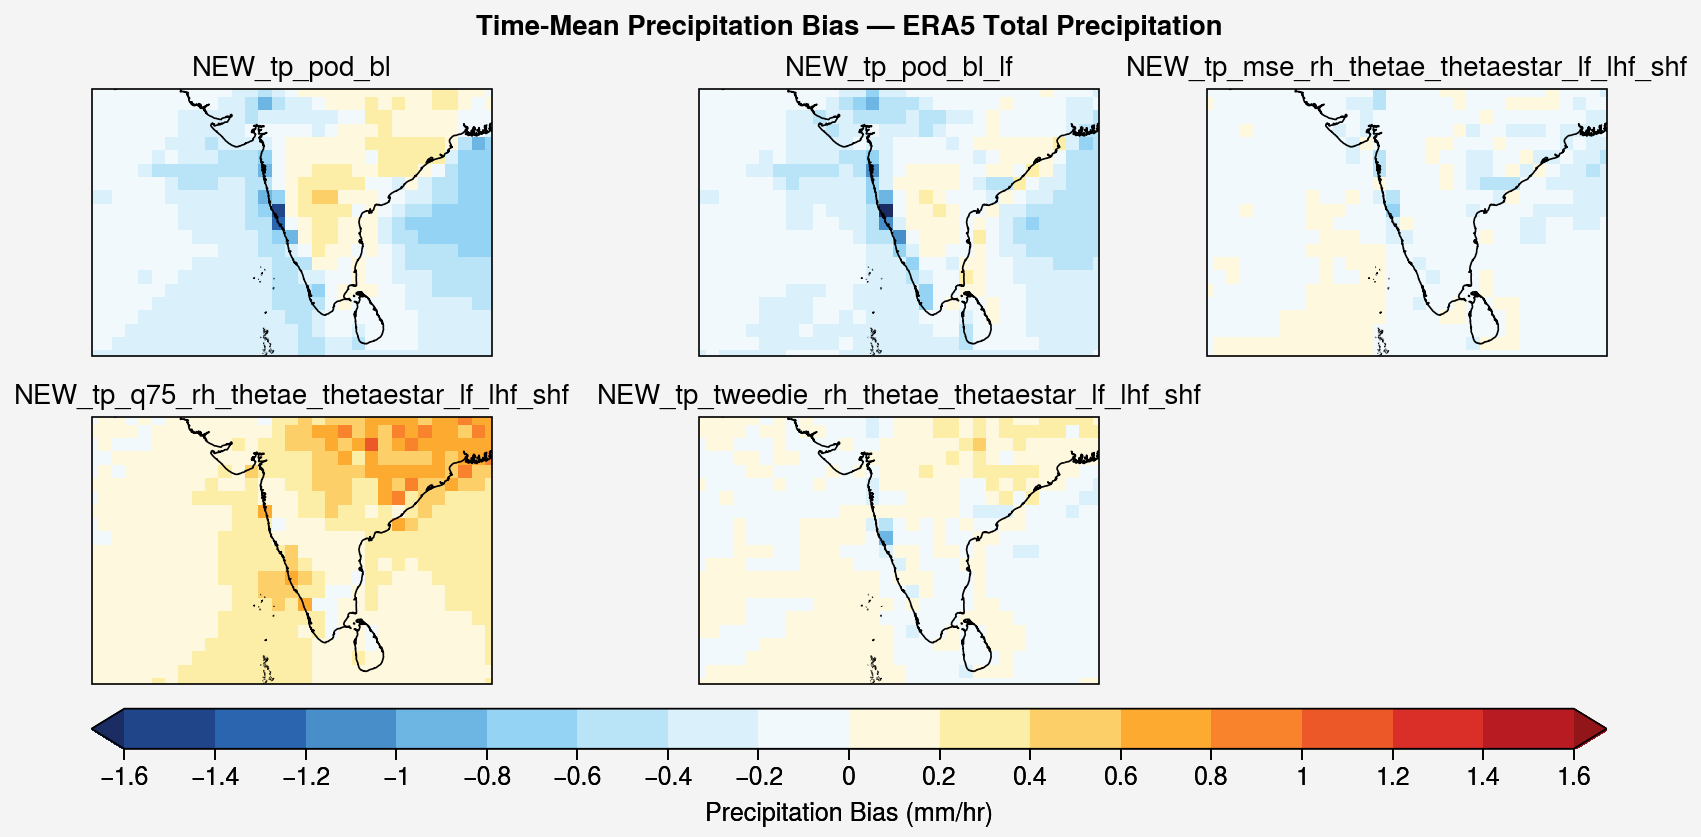

In [51]:
plot_bias_maps(resultspr,'Time-Mean Precipitation Bias — IMERGV06 Precipitation Rate')
plot_bias_maps(resultstp,'Time-Mean Precipitation Bias — ERA5 Total Precipitation')

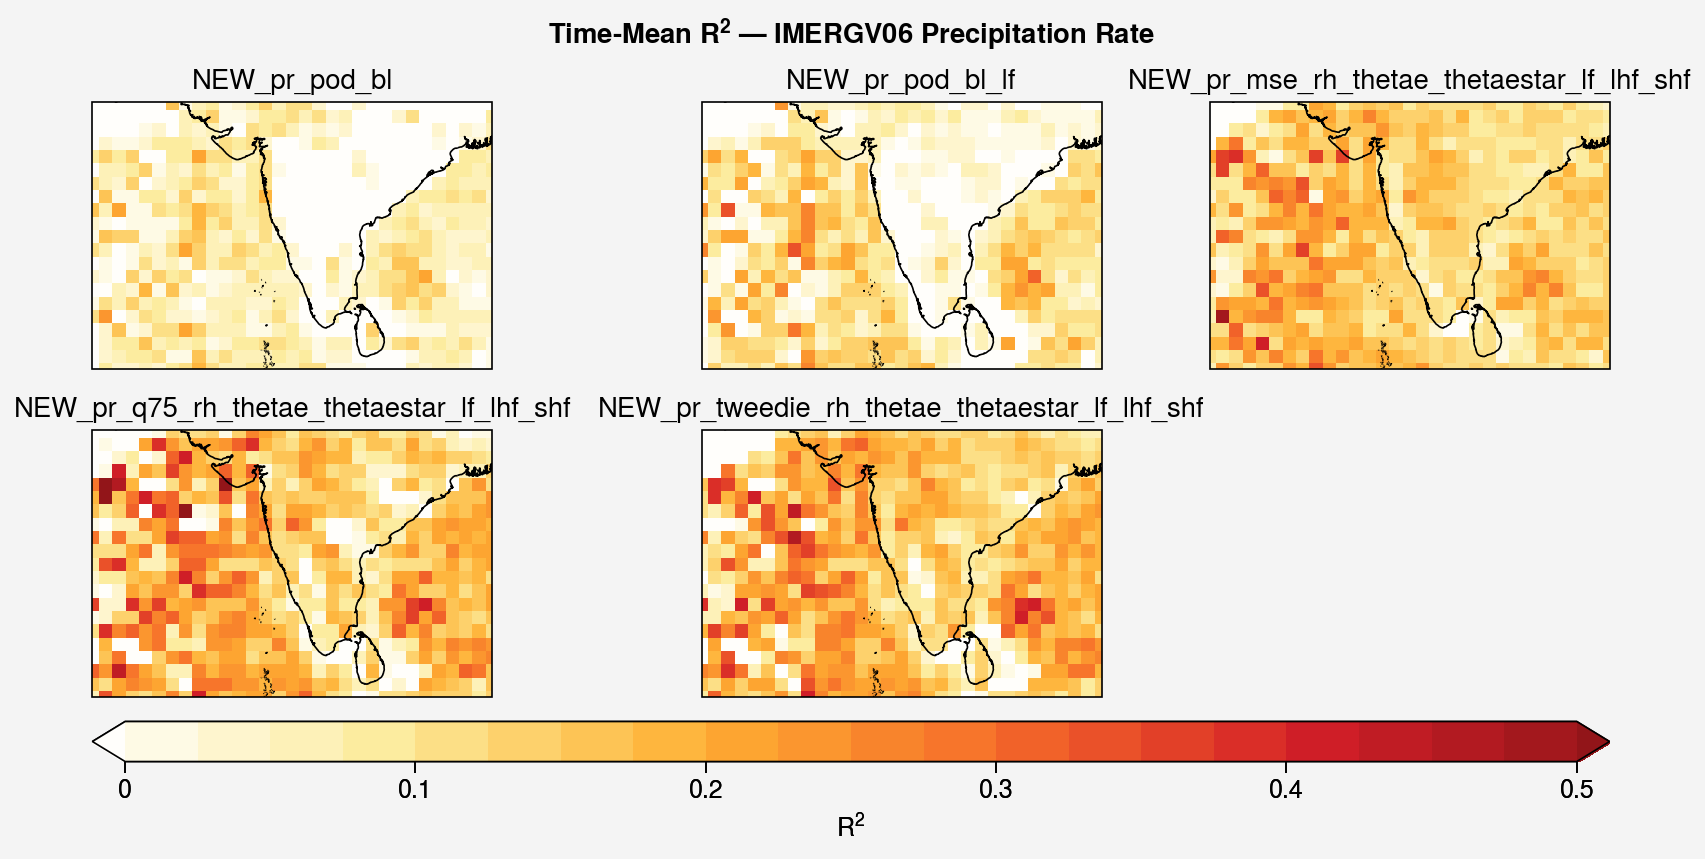

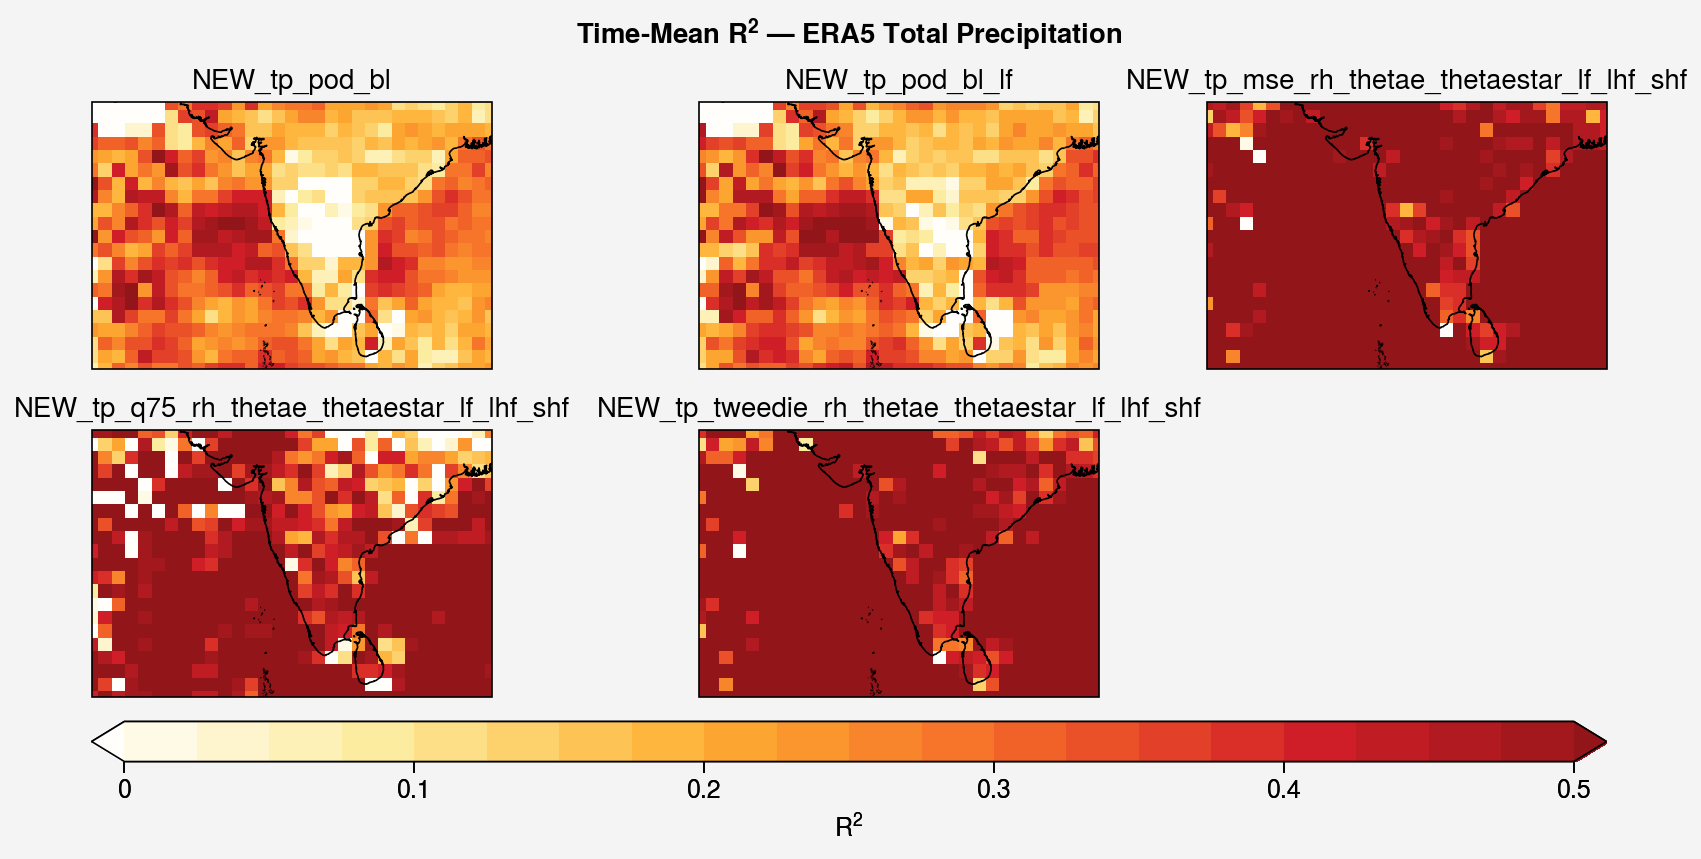

In [52]:
plot_r2_maps(resultspr,'Time-Mean R$^2$ — IMERGV06 Precipitation Rate')
plot_r2_maps(resultstp,'Time-Mean R$^2$ — ERA5 Total Precipitation')

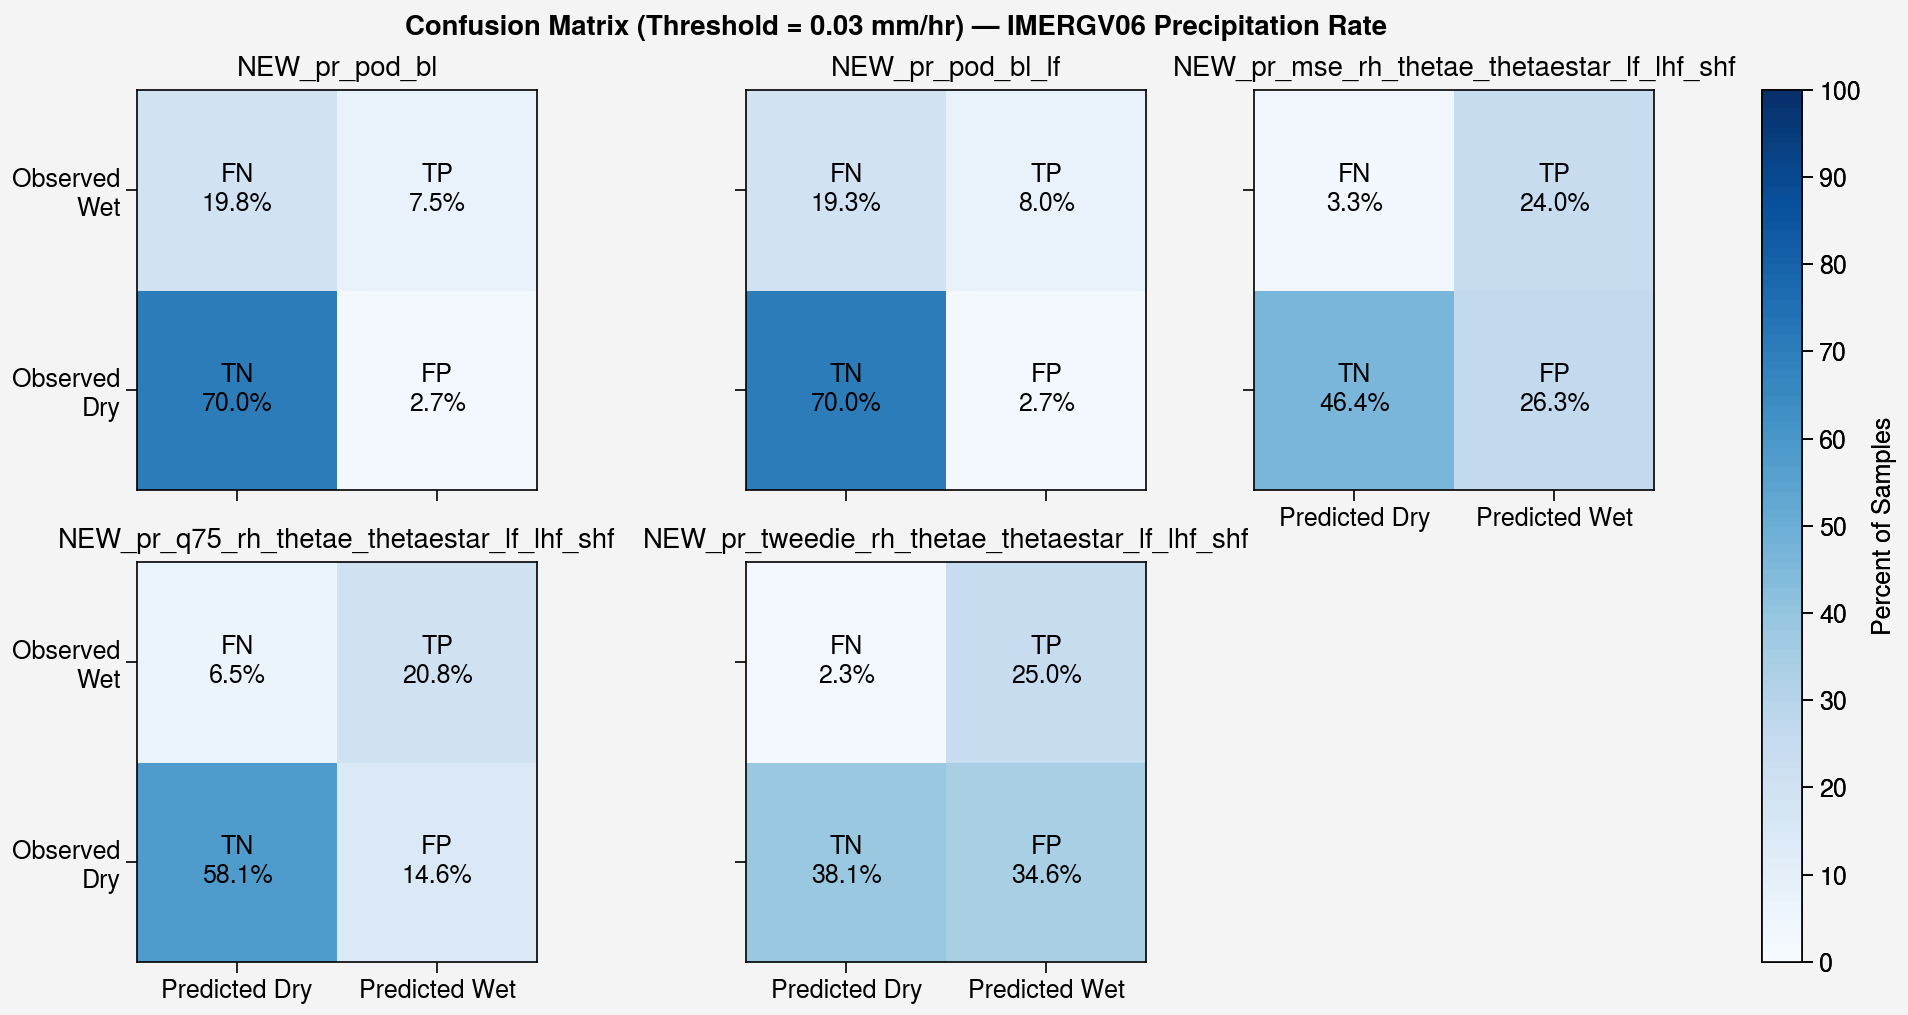

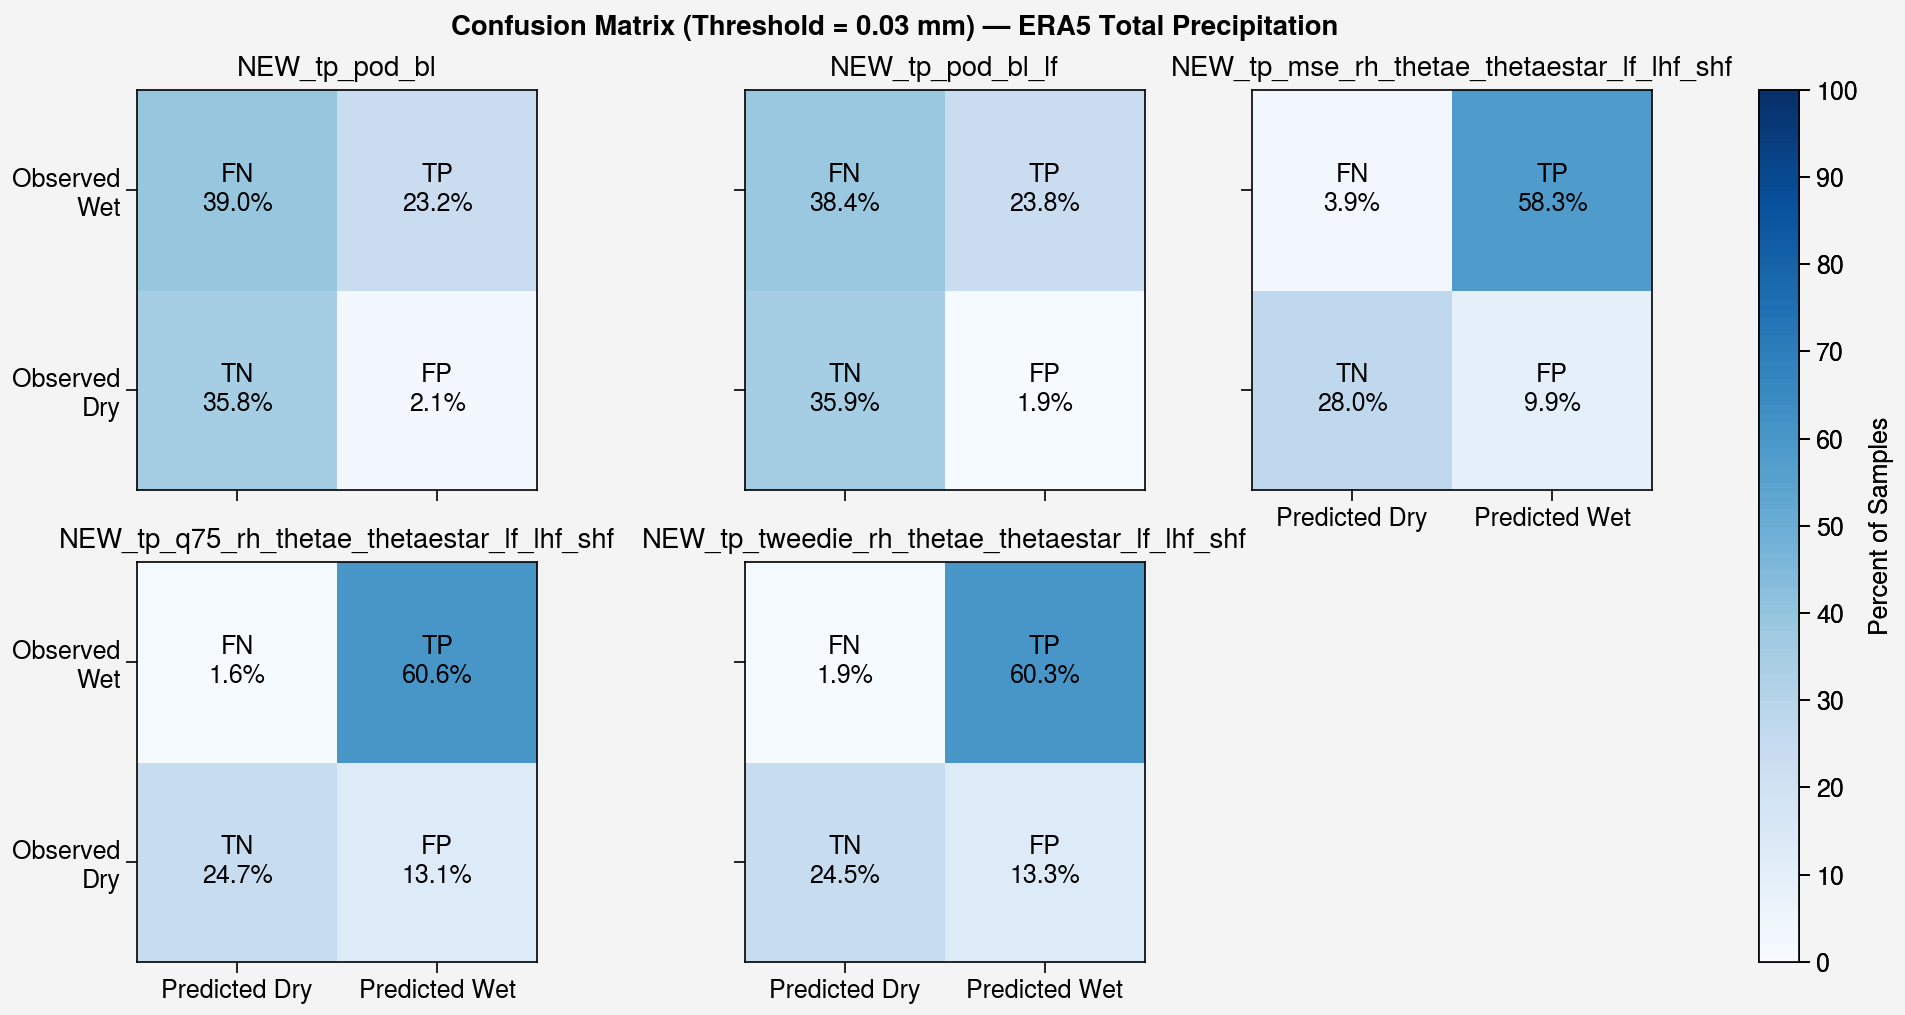

In [53]:
plot_confusion_matrix(resultspr,f'Confusion Matrix (Threshold = {PRTHRESH} mm/hr) — IMERGV06 Precipitation Rate')
plot_confusion_matrix(resultstp,f'Confusion Matrix (Threshold = {PRTHRESH} mm) — ERA5 Total Precipitation')